In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

### Questions
* What is the quality of the curve fitting within Meltome Atlas overall and within the subset that maps to yeast nodes?
* How many proteins have a `stability-class` value from the Meltome Atlas?
* How many proteins that are not `in_complex` have a stability class value from the Meltome Atlas?
* How many proteins that do not engage chaperones have a stability class value from the Meltome Atlas?
* What are the DeepTMHMM classifications of the protein in the Meltome Atlas for yeast?
* For proteins in the Meltome Atlas, how many have large predicted IDR content?
* When using `stability-class`, `Tm`, or `AUC` as proxies for stability, do any trends emerge in the regarding stability of proteins in top10% of nodes by degree centrality?

### Initial data exploration

In [44]:
melt = pd.read_csv("meltome-atlas-ma_0010.txt", sep="\t")
melt.rename(columns={"Protein ID":"id", 
                     "Melting point [°C]":"melting-point", 
                     "Protein stability class":"stability-class", 
                     "AUC":"AUC", 
                     "Curve fit converged":"fit-converged", 
                     "R2 of curve fit":"R2"}, inplace=True)
melt["UniProtKB-AC"] = melt["id"].str.split("_").str[0]

nodes = pd.read_pickle("../5-s288c-nodes-final-per-node.pkl")

In [45]:
melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2166 entries, 0 to 2165
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2166 non-null   object 
 1   melting-point    1949 non-null   float64
 2   stability-class  2166 non-null   object 
 3   AUC              2165 non-null   float64
 4   fit-converged    2166 non-null   bool   
 5   R2               2165 non-null   float64
 6   UniProtKB-AC     2166 non-null   object 
dtypes: bool(1), float64(3), object(3)
memory usage: 103.8+ KB


In [46]:
melt.columns

Index(['id', 'melting-point', 'stability-class', 'AUC', 'fit-converged', 'R2',
       'UniProtKB-AC'],
      dtype='object')

In [47]:
print (melt["UniProtKB-AC"].head(15))

0     A0A023PXQ4
1         A5Z2X5
2         O13297
3         O13516
4         O13539
5         O13547
6         O13563
7         O14455
8         O14467
9         O14468
10        O43137
11        O60200
12        O74700
13        O75012
14        O94742
Name: UniProtKB-AC, dtype: object


In [48]:
nodes = nodes.merge(melt, on="UniProtKB-AC", how="left")
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Columns: 210 entries, node to R2
dtypes: bool(2), float64(103), int64(39), object(66)
memory usage: 6.2+ MB


In [49]:
# add decile bin labels based on degree_centrality
nodes["degree_bin"] = pd.qcut(
    nodes["degree_centrality"],
    q=[0, 0.9, 1.0],   # bottom 90% and top 10%
    labels=["0-90", "90-100"]
)

#### What is the quality of the curve fitting within Meltome Atlas overall and within the subset that maps to yeast nodes?

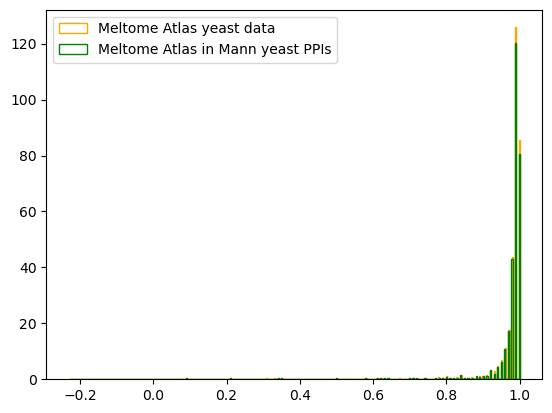

In [50]:
plt.clf()
plt.hist(melt["R2"], color="orange", label="Meltome Atlas yeast data", bins="fd", histtype="step", density=True)
plt.hist(nodes["R2"], color="green", label="Meltome Atlas in Mann yeast PPIs", bins="fd", histtype="step", density=True)
plt.legend()
plt.show()

* A reasonable filtering cutoff like 0.9 should be applied to remove poor samples

#### How many proteins have a stability-class value from the Meltome Atlas?

In [51]:
nodes["stability-class"].value_counts()

stability-class
medium        1311
non-stable     207
non-melter     173
stable         153
Name: count, dtype: int64

* 1,844 proteins in the Mann MS dataset have a stability classification from the Meltome Atlas

#### How many proteins that are not in_complex have a stability class value from the Meltome Atlas?

In [52]:
temp = nodes[nodes["in_complex"] == 1]
temp["stability-class"].value_counts()

stability-class
medium        533
non-melter     81
non-stable     78
stable         62
Name: count, dtype: int64

* 754 proteins that bind another protein to form a complex are in the Meltome Atlas

In [53]:
temp = nodes[nodes["in_complex"] == 0]
temp["stability-class"].value_counts()

stability-class
medium        778
non-stable    129
non-melter     92
stable         91
Name: count, dtype: int64

* 1090 proteins that do not bind another protein to form a complex are in the Meltome Atlas

#### What are the DeepTMHMM classifications of the protein in the Meltome Atlas for yeast?

In [54]:
nodes["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     3273
TM        457
SP         84
SP+TM      61
BETA        1
Name: count, dtype: int64

In [55]:
# set of stable proteins
temp = nodes[nodes["stability-class"] == "stable"]
temp["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     141
TM         6
SP         5
SP+TM      1
Name: count, dtype: int64

In [56]:
# set of medium stability proteins
temp = nodes[nodes["stability-class"] == "medium"]
temp["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     1230
TM         40
SP         33
SP+TM       7
Name: count, dtype: int64

In [57]:
# set of non-stable proteins
temp = nodes[nodes["stability-class"] == "non-stable"]
temp["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     186
TM        17
SP         3
SP+TM      1
Name: count, dtype: int64

In [58]:
# set of non-melter proteins
temp = nodes[nodes["stability-class"] == "non-melter"]
temp["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     157
SP         8
TM         5
SP+TM      3
Name: count, dtype: int64

In [59]:
# across all proteins in the Meltome Atlas experiment
temp = nodes[~nodes["stability-class"].isna()]
temp["DeepTMHMM_class"].value_counts()

DeepTMHMM_class
GLOB     1714
TM         68
SP         49
SP+TM      12
Name: count, dtype: int64

* The Meltome Atlas experiments predominantly covered the globular and secreted portions of the yeast proteome represented by the Mann MS experiments
* Percent coverage of the Mann experiment by Meltome Atlas and stratified by DeepTMHMM_class is:
    * GLOB: (1714 / 3273) * 100% = 52.4%
    * TM: (68 / 457) * 100% = 14.9%
    * SP: (49 / 84) * 100% = 58.3%
    * SP+TM: (12 / 61) * 100% = 19.7%
    * BETA: (0 / 1) * 100% = 0%
* Even for GLOB and SP classes, coverage is only ~50% of the nodes

#### For proteins in the Meltome Atlas, how many have large predicted IDR content?

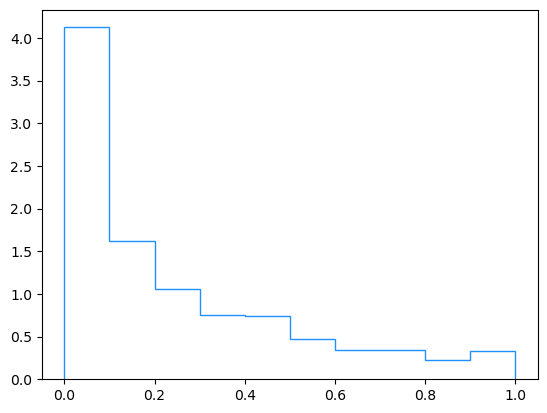

1844
1391


In [60]:
temp = nodes[~nodes["stability-class"].isna()]

plt.clf()
plt.hist(temp["disorder_fraction"], histtype="step", density=True, color="dodgerblue")
plt.show()

print (len(temp))
temp2 = temp[temp["disorder_fraction"] < 0.4]
print (len(temp2))

#### How many proteins that do not engage chaperones have a stability class value from the Meltome Atlas?

In [61]:
# number of proteins that do not engage a chaperone based on the Mann data
temp = nodes[nodes["interacting_chaperones"].str.len() == 0]
len(temp)

3361

In [62]:
# number of proteins that do not engage a chaperone and have a stability-class from Meltome Atlas
temp = temp[~temp["stability-class"].isna()]
len(temp)

1457

### Cross-ref to get set of proteins not in a complex, not engaged by chaperones, etc.

In [63]:
# filter out everything that may have been problematic in the Meltome Atlas experiments
filtered = nodes[(nodes["interacting_chaperones"].str.len() == 0) &
                 (nodes["disorder_fraction"] < 0.4)               &
                 (nodes["in_complex"] == 0)                       & 
                 (nodes["DeepTMHMM_class"].isin(["GLOB", "SP"]))  &
                 (~nodes["stability-class"].isna())               &
                 (nodes["R2"] >= 0.9)
    ]

len(filtered)

577

In [64]:
filtered["stability-class"].value_counts()

stability-class
medium        462
non-stable     70
stable         32
non-melter     13
Name: count, dtype: int64

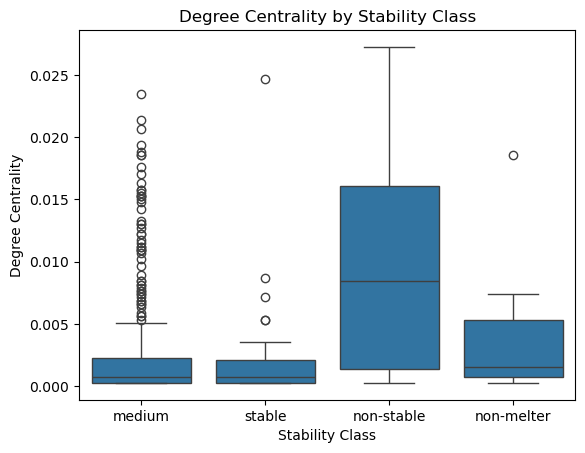

In [65]:
sns.boxplot(
    data=filtered,
    x="stability-class",
    y="degree_centrality"
)

plt.xlabel("Stability Class")
plt.ylabel("Degree Centrality")
plt.title("Degree Centrality by Stability Class")
plt.show()

/tmp/ipykernel_657008/3449251045.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = filtered.groupby(["degree_bin", "stability-class"]).size().reset_index(name="count")
/tmp/ipykernel_657008/3449251045.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fractions = counts.groupby("degree_bin").apply(
/tmp/ipykernel_657008/3449251045.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitl

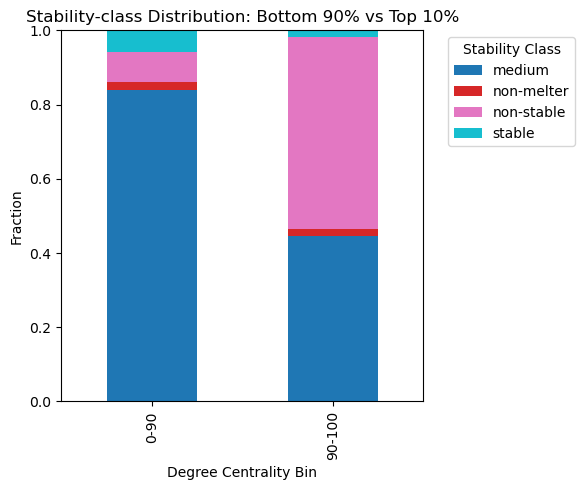

In [66]:
# count proteins per bin × stability-class
counts = filtered.groupby(["degree_bin", "stability-class"]).size().reset_index(name="count")

# normalize to fractions within each bin
fractions = counts.groupby("degree_bin").apply(
    lambda g: g.assign(fraction=g["count"] / g["count"].sum())
).reset_index(drop=True)

fractions_pivot = fractions.pivot(
    index="degree_bin", 
    columns="stability-class", 
    values="fraction"
).fillna(0)

# ensure order of bins
fractions_pivot = fractions_pivot.reindex(["0-90", "90-100"])

ax = fractions_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5),
    colormap="tab10"
)

ax.set_ylabel("Fraction")
ax.set_ylim(0, 1)
ax.set_xlabel("Degree Centrality Bin")
ax.set_title("Stability-class Distribution: Bottom 90% vs Top 10%")
ax.legend(title="Stability Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_657008/2131861287.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = filtered.groupby(["stability-class", "degree_bin"]).size().reset_index(name="count")
/tmp/ipykernel_657008/2131861287.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fractions = counts.groupby("stability-class").apply(


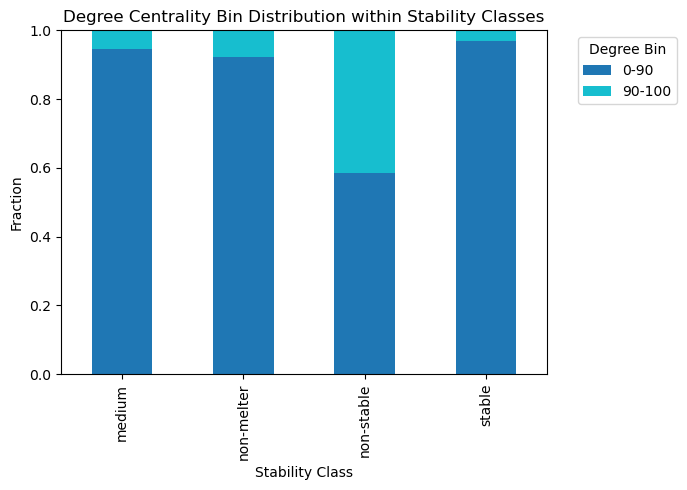

In [67]:
# count proteins per stability-class × degree_bin
counts = filtered.groupby(["stability-class", "degree_bin"]).size().reset_index(name="count")

# normalize within each stability class
fractions = counts.groupby("stability-class").apply(
    lambda g: g.assign(fraction=g["count"] / g["count"].sum())
).reset_index(drop=True)

# pivot so stability-class is the index and degree_bin the columns
fractions_pivot = fractions.pivot(
    index="stability-class",
    columns="degree_bin",
    values="fraction"
).fillna(0)

# ensure bin order
fractions_pivot = fractions_pivot[["0-90", "90-100"]]

# plot
ax = fractions_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    colormap="tab10"
)

ax.set_ylabel("Fraction")
ax.set_ylim(0, 1)
ax.set_xlabel("Stability Class")
ax.set_title("Degree Centrality Bin Distribution within Stability Classes")
ax.legend(title="Degree Bin", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [68]:
# chi-squared test
table = pd.crosstab(filtered["stability-class"], filtered["degree_bin"])

print("Contingency table:")
print(table)

# Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("\nExpected counts:")
print(expected)

Contingency table:
degree_bin       0-90  90-100
stability-class              
medium            437      25
non-melter         12       1
non-stable         41      29
stable             31       1

Chi-square statistic: 91.74791082059961
Degrees of freedom: 3
p-value: 9.227646568844374e-20

Expected counts:
[[417.16117851  44.83882149]
 [ 11.73830156   1.26169844]
 [ 63.20623917   6.79376083]
 [ 28.89428076   3.10571924]]


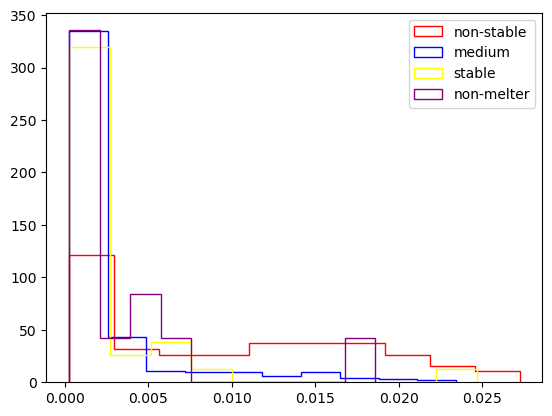

In [69]:
plt.clf()
plt.hist(filtered[filtered["stability-class"] == "non-stable"]["degree_centrality"], label="non-stable", color="red", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "medium"]["degree_centrality"], label="medium", color="blue", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "stable"]["degree_centrality"], label="stable", color="yellow", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "non-melter"]["degree_centrality"], label="non-melter", color="purple", density=True, histtype="step")
plt.legend()

#### Let's take a more blue sky approach to the data and only filter for curve-fit quality

In [70]:
filtered = nodes[(~nodes["stability-class"].isna()) &
                 (nodes["R2"] >= 0.9)
    ]

len(filtered)

1745

In [71]:
filtered["stability-class"].value_counts()

stability-class
medium        1297
non-stable     205
stable         147
non-melter      96
Name: count, dtype: int64

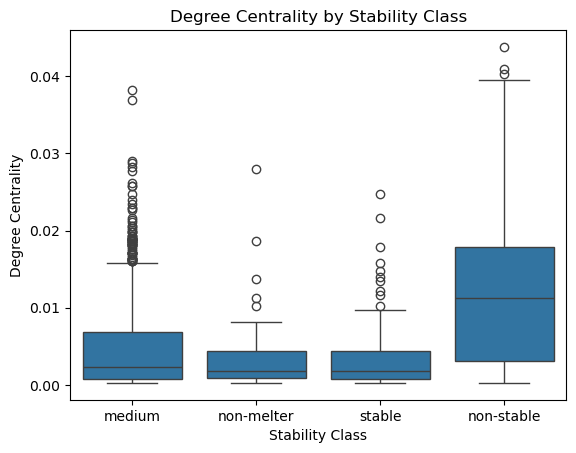

In [72]:
sns.boxplot(
    data=filtered,
    x="stability-class",
    y="degree_centrality"
)

plt.xlabel("Stability Class")
plt.ylabel("Degree Centrality")
plt.title("Degree Centrality by Stability Class")
plt.show()

/tmp/ipykernel_657008/2131861287.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = filtered.groupby(["stability-class", "degree_bin"]).size().reset_index(name="count")
/tmp/ipykernel_657008/2131861287.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fractions = counts.groupby("stability-class").apply(


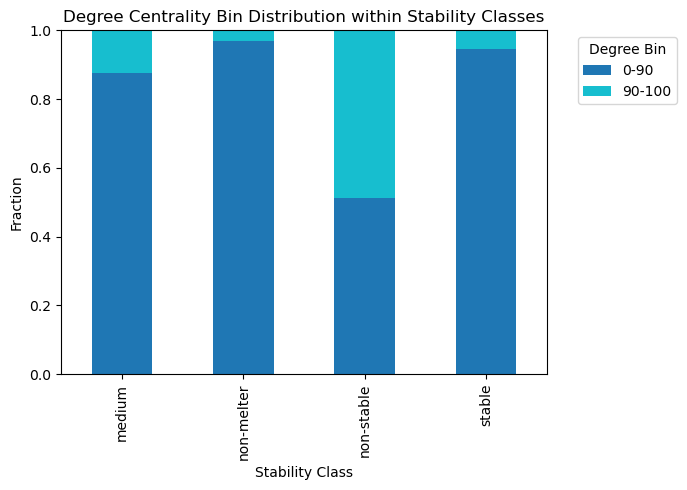

In [73]:
# count proteins per stability-class × degree_bin
counts = filtered.groupby(["stability-class", "degree_bin"]).size().reset_index(name="count")

# normalize within each stability class
fractions = counts.groupby("stability-class").apply(
    lambda g: g.assign(fraction=g["count"] / g["count"].sum())
).reset_index(drop=True)

# pivot so stability-class is the index and degree_bin the columns
fractions_pivot = fractions.pivot(
    index="stability-class",
    columns="degree_bin",
    values="fraction"
).fillna(0)

# ensure bin order
fractions_pivot = fractions_pivot[["0-90", "90-100"]]

# plot
ax = fractions_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    colormap="tab10"
)

ax.set_ylabel("Fraction")
ax.set_ylim(0, 1)
ax.set_xlabel("Stability Class")
ax.set_title("Degree Centrality Bin Distribution within Stability Classes")
ax.legend(title="Degree Bin", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [74]:
# chi-squared test
table = pd.crosstab(filtered["stability-class"], filtered["degree_bin"])

print("Contingency table:")
print(table)

# Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("\nExpected counts:")
print(expected)

Contingency table:
degree_bin       0-90  90-100
stability-class              
medium           1136     161
non-melter         93       3
non-stable        105     100
stable            139       8

Chi-square statistic: 204.42178325233832
Degrees of freedom: 3
p-value: 4.673976801178927e-44

Expected counts:
[[1094.83151862  202.16848138]
 [  81.03610315   14.96389685]
 [ 173.04584527   31.95415473]
 [ 124.08653295   22.91346705]]


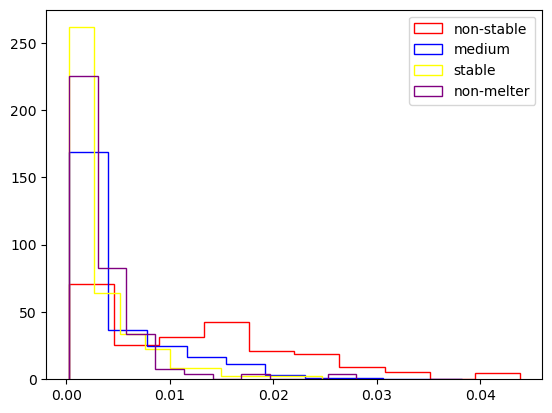

In [75]:
plt.clf()
plt.hist(filtered[filtered["stability-class"] == "non-stable"]["degree_centrality"], label="non-stable", color="red", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "medium"]["degree_centrality"], label="medium", color="blue", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "stable"]["degree_centrality"], label="stable", color="yellow", density=True, histtype="step")
plt.hist(filtered[filtered["stability-class"] == "non-melter"]["degree_centrality"], label="non-melter", color="purple", density=True, histtype="step")
plt.legend()